In [29]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import ast
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import MultinomialNB, BernoulliNB, CategoricalNB
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load dataset
df = pd.read_csv("labelled_merged_dataset.csv")
pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', None)

# Step 3: Create IsChain (if the restaurant is in multiple locations)
title_counts = df['Title'].value_counts()
df['IsChain'] = df['Title'].apply(lambda x: 1 if title_counts[x] > 1 else 0)

# Step 4: Create tag_count from Categories column
def parse_categories(x):
    try:
        return len(ast.literal_eval(x)) if pd.notnull(x) else 0
    except:
        return 0
df['tag_count'] = df['Categories'].apply(parse_categories)

# Step 5: Convert Rating to binary label
df['RatingBinary'] = df['Rating'].map({'Good': 1, 'Bad': 0})
df.head()

,Title,Category,Rating,Address,Categories,ZCTA,NAME,Median_Income,Population,Males_20yrs_age,Males_30yrs_age,Males_60yrs_age,Females_20yrs_age,Females_30yrs_age,Females_60yrs_age,Asian,American,Hispanic_or_Latino,IsChain,tag_count,RatingBinary
0,Dairy Queen Grill & Chill,Fast food restaurant,Bad,"Dairy Queen Grill & Chill, 3143 US-280, Alexan...","['Fast food restaurant', 'Ice cream shop']",35010,ZCTA5 35010,46730,20406,414,658,409,246,636,434,107,1864,899,1,2,0
1,Jake's Restaurant,American restaurant,Good,"Jake's Restaurant, 16 Broad St, Alexander City...",['American restaurant'],35010,ZCTA5 35010,46730,20406,414,658,409,246,636,434,107,1864,899,1,1,1
2,Carib Kitchen,Caribbean restaurant,Good,"Carib Kitchen, 68 Broad St, Alexander City, AL...",['Caribbean restaurant'],35010,ZCTA5 35010,46730,20406,414,658,409,246,636,434,107,1864,899,0,1,1
3,Cazadores Mexican Restaurant,Mexican restaurant,Good,"Cazadores Mexican Restaurant, 910 Cherokee Rd,...",['Mexican restaurant'],35010,ZCTA5 35010,46730,20406,414,658,409,246,636,434,107,1864,899,1,1,1
4,La Posada Mexican Grill,Mexican restaurant,Bad,"La Posada Mexican Grill, 3714 US-280, Alexande...","['Mexican restaurant', 'Latin American restaur...",35010,ZCTA5 35010,46730,20406,414,658,409,246,636,434,107,1864,899,1,2,0


Cleaned Data Before NB Modeling: 

   Median_Income  Population  American  Asian  Hispanic_or_Latino  IsChain  tag_count  RatingBinary
0          46730       20406      1864    107                 899        1          2             0
1          46730       20406      1864    107                 899        1          1             1
2          46730       20406      1864    107                 899        0          1             1
3          46730       20406      1864    107                 899        1          1             1
4          46730       20406      1864    107                 899        1          2             0

 Training Set Sample (80%): 

   Median_Income  Population  American     Asian  Hispanic_or_Latino  IsChain  tag_count  RatingBinary
0       0.318987    0.065737  0.028712  0.003848            0.007781      0.0   0.076923             1
1       0.312026    0.656278  0.062807  0.098284            0.261424      1.0   0.230769             0
2       0.225416    0.053

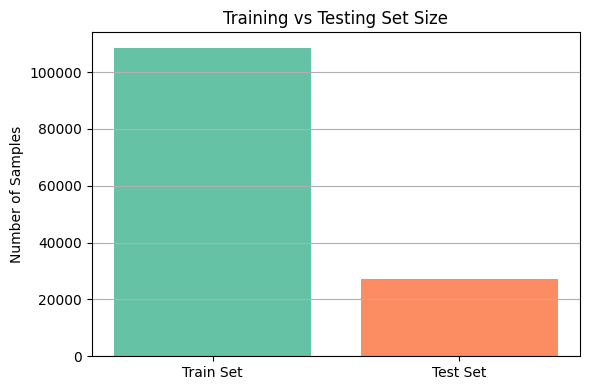

In [30]:
# Step 6: Select features and target
features = ['Median_Income', 'Population', 'American', 'Asian', 'Hispanic_or_Latino', 'IsChain', 'tag_count']
X = df[features]
y = df['RatingBinary']

# Step 7: Scale features (MinMax for Multinomial and Bernoulli)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Step 8: Split into train/test sets (disjoint)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)

# DISPLAY CLEANED DATA, TRAINING SET, TEST SET
train_sample_df = pd.DataFrame(X_train, columns=features)
train_sample_df['RatingBinary'] = y_train.values

test_sample_df = pd.DataFrame(X_test, columns=features)
test_sample_df['RatingBinary'] = y_test.values

cleaned_data_df = df[features + ['RatingBinary']].copy()

print("Cleaned Data Before NB Modeling: \n")
print(cleaned_data_df.head())

print("\n Training Set Sample (80%): \n")
print(train_sample_df.head())

print("\n Testing Set Sample (20%): \n")
print(test_sample_df.head())

# TRAIN/TEST SIZE BAR CHART
sizes = [len(train_sample_df), len(test_sample_df)]
labels = ['Train Set', 'Test Set']
colors = ['#66c2a5', '#fc8d62']

plt.figure(figsize=(6, 4))
plt.bar(labels, sizes, color=colors)
plt.title("Training vs Testing Set Size")
plt.ylabel("Number of Samples")
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

In [31]:
print("Data Used for MultinomialNB: \n")
print(pd.DataFrame(X_train, columns=features).head())

# MODEL 1: Multinomial Naive Bayes
mnb = MultinomialNB()
mnb.fit(X_train, y_train)
mnb_pred = mnb.predict(X_test)
mnb_acc = accuracy_score(y_test, mnb_pred)
mnb_cm = confusion_matrix(y_test, mnb_pred)

Data Used for MultinomialNB: 

   Median_Income  Population  American     Asian  Hispanic_or_Latino  IsChain  tag_count
0       0.318987    0.065737  0.028712  0.003848            0.007781      0.0   0.076923
1       0.312026    0.656278  0.062807  0.098284            0.261424      1.0   0.230769
2       0.225416    0.053282  0.004187  0.001387            0.001147      1.0   0.076923
3       0.199707    0.502724  0.031343  0.006656            0.294054      0.0   0.230769
4       0.170407    0.260189  0.150257  0.002097            0.009747      1.0   0.461538


In [32]:
# MODEL 2: Bernoulli Naive Bayes
X_train_bin = (X_train > 0.5).astype(int)
X_test_bin = (X_test > 0.5).astype(int)
bnb = BernoulliNB()
bnb.fit(X_train_bin, y_train)
bnb_pred = bnb.predict(X_test_bin)
bnb_acc = accuracy_score(y_test, bnb_pred)
bnb_cm = confusion_matrix(y_test, bnb_pred)
print("Data Used for BernoulliNB: \n")
print(pd.DataFrame(X_train_bin, columns=features).head())

Data Used for BernoulliNB: 

   Median_Income  Population  American  Asian  Hispanic_or_Latino  IsChain  tag_count
0              0           0         0      0                   0        0          0
1              0           1         0      0                   0        1          0
2              0           0         0      0                   0        1          0
3              0           1         0      0                   0        0          0
4              0           0         0      0                   0        1          0


In [33]:
#MODEL 3: Categorical Naive Bayes
X_cat = X.copy()
for col in X_cat.columns:
    X_cat[col] = pd.qcut(X_cat[col], q=4, labels=False, duplicates='drop')

X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(X_cat, y, test_size=0.2, stratify=y, random_state=42)
cnb = CategoricalNB()
cnb.fit(X_train_cat, y_train_cat)
cnb_pred = cnb.predict(X_test_cat)
cnb_acc = accuracy_score(y_test_cat, cnb_pred)
cnb_cm = confusion_matrix(y_test_cat, cnb_pred)
print("Data Used for CategoricalNB: \n")
print(X_train_cat.head())

Data Used for CategoricalNB: 

        Median_Income  Population  American  Asian  Hispanic_or_Latino  IsChain  tag_count
132885              2           0         1      0                   0        0          0
72380               2           3         2      3                   3        0          2
62682               1           0         0      0                   0        0          0
26334               0           3         1      1                   3        0          2
62167               0           1         3      0                   0        0          3


In [34]:
#RESULTS
print("MODEL RESULTS: \n")
print("MultinomialNB Accuracy: ", mnb_acc)
print("\n Confusion Matrix:\n", mnb_cm)

print("\n BernoulliNB Accuracy: ", bnb_acc)
print("\n Confusion Matrix:\n", bnb_cm)

print("\n CategoricalNB Accuracy: ", cnb_acc)
print("\n Confusion Matrix:\n", cnb_cm)

MODEL RESULTS: 

MultinomialNB Accuracy:  0.6547684827052713

 Confusion Matrix:
 [[ 6922  6873]
 [ 2499 10853]]

 BernoulliNB Accuracy:  0.6509006520057465

 Confusion Matrix:
 [[ 7302  6493]
 [ 2984 10368]]

 CategoricalNB Accuracy:  0.5745754595351236

 Confusion Matrix:
 [[7661 6134]
 [5415 7937]]


<ipython-input-35-73c7269c0652>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=results, palette='Set2')


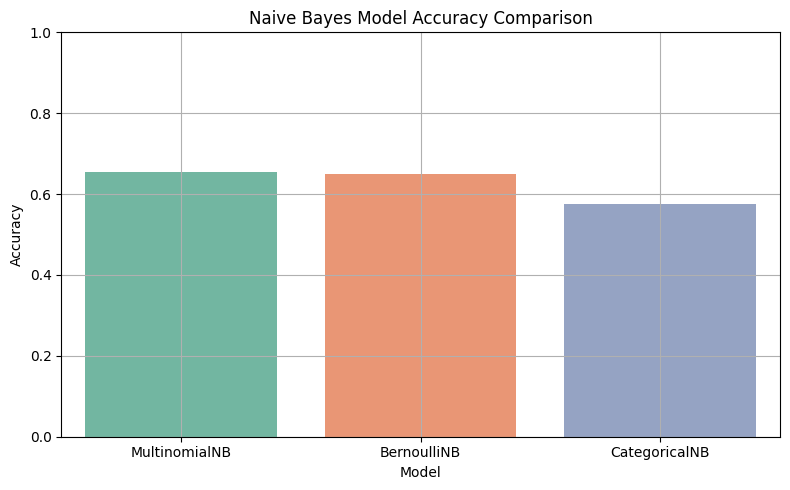

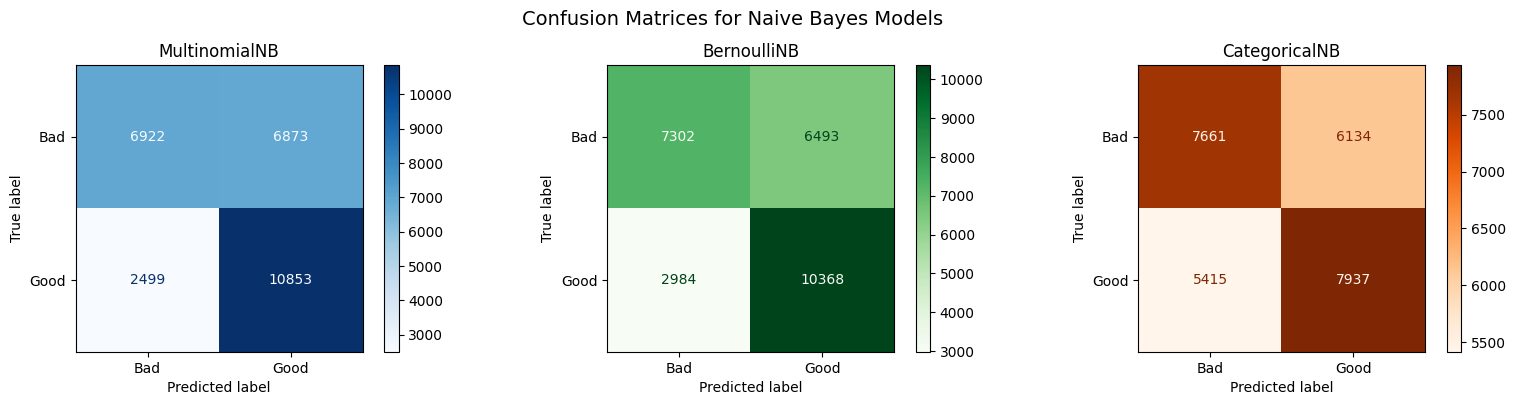

In [35]:
# ACCURACY COMPARISON PLOT
results = pd.DataFrame({
    'Model': ['MultinomialNB', 'BernoulliNB', 'CategoricalNB'],
    'Accuracy': [mnb_acc, bnb_acc, cnb_acc]
})

plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Accuracy', data=results, palette='Set2')
plt.title('Naive Bayes Model Accuracy Comparison')
plt.ylim(0, 1)
plt.grid(True)
plt.tight_layout()
plt.show()

# CONFUSION MATRIX VISUALIZATION
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ConfusionMatrixDisplay(mnb_cm, display_labels=["Bad", "Good"]).plot(ax=axes[0], cmap="Blues", values_format="d")
axes[0].set_title("MultinomialNB")

ConfusionMatrixDisplay(bnb_cm, display_labels=["Bad", "Good"]).plot(ax=axes[1], cmap="Greens", values_format="d")
axes[1].set_title("BernoulliNB")

ConfusionMatrixDisplay(cnb_cm, display_labels=["Bad", "Good"]).plot(ax=axes[2], cmap="Oranges", values_format="d")
axes[2].set_title("CategoricalNB")

plt.suptitle("Confusion Matrices for Naive Bayes Models", fontsize=14)
plt.tight_layout()
plt.show()

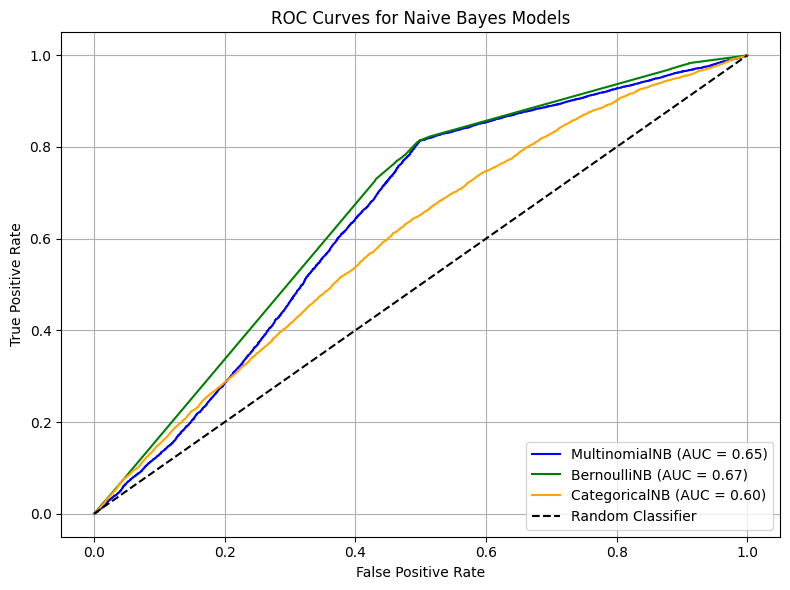

In [36]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get predicted probabilities for each model
mnb_probs = mnb.predict_proba(X_test)[:, 1]
bnb_probs = bnb.predict_proba(X_test_bin)[:, 1]
cnb_probs = cnb.predict_proba(X_test_cat)[:, 1]

# Calculate AUC scores
mnb_auc = roc_auc_score(y_test, mnb_probs)
bnb_auc = roc_auc_score(y_test, bnb_probs)
cnb_auc = roc_auc_score(y_test_cat, cnb_probs)

# Compute ROC curves
fpr_mnb, tpr_mnb, _ = roc_curve(y_test, mnb_probs)
fpr_bnb, tpr_bnb, _ = roc_curve(y_test, bnb_probs)
fpr_cnb, tpr_cnb, _ = roc_curve(y_test_cat, cnb_probs)

# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_mnb, tpr_mnb, label=f"MultinomialNB (AUC = {mnb_auc:.2f})", color='blue')
plt.plot(fpr_bnb, tpr_bnb, label=f"BernoulliNB (AUC = {bnb_auc:.2f})", color='green')
plt.plot(fpr_cnb, tpr_cnb, label=f"CategoricalNB (AUC = {cnb_auc:.2f})", color='orange')
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")

plt.title("ROC Curves for Naive Bayes Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()